# ShakeMap + Ground Failure + PAGER: San Andreas M7.6 Demo

**BSSC 2014 scenario** — North San Andreas fault (SAP+SAS segments), M7.6  
Full USGS natural hazards pipeline: ShakeMap → PAGER → Ground Failure → Visualization

Run cells top-to-bottom. The full pipeline takes about 2 minutes.

## 1. Setup

In [1]:
import os, json, shutil
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

EVENT = 'bssc2014nsanandreassapsassha_m7p6_se'
os.environ['EVENT'] = EVENT

EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'
GF_OUT    = Path.home() / 'gf_output' / EVENT
CA_DATA   = Path('/workspaces/shakemap-codespaces/data/california_inputs')
PAGER_PNG = Path('/workspaces/shakemap-codespaces/data/pager/onepager.png')

# Helper: parse the ShakeMap grid into arrays
def load_grid(grid_xml):
    ns = {'sm': 'http://earthquake.usgs.gov/eqcenter/shakemap'}
    root = ET.parse(grid_xml).getroot()
    fields = {f.attrib['name']: i
              for i, f in enumerate(root.findall('sm:grid_field', ns))}
    data = np.fromstring(
        root.find('sm:grid_data', ns).text, sep=' ')
    data = data.reshape(-1, len(fields))
    return data, fields

print(f'Event:     {EVENT}')
print(f'CA data:   exists={CA_DATA.exists()}')
print(f'PAGER PNG: exists={PAGER_PNG.exists()}')

Event:     bssc2014nsanandreassapsassha_m7p6_se
CA data:   exists=True
PAGER PNG: exists=True


## 2. ShakeMap inputs

Two files define the scenario:
- **`event.xml`** — origin parameters: location, depth, magnitude, time
- **`rupture.json`** — finite fault geometry (the 3D fault plane)

In [2]:
# Parse and display event.xml
root = ET.parse(EVENT_DIR / 'event.xml').getroot()
ev = root.attrib
print('=== Event parameters ===')
for k, v in ev.items():
    print(f'  {k:30s}: {v}')

=== Event parameters ===
  id                            : bssc2014nsanandreassapsassha_m7p6_se
  netid                         : bssc2014
  network                       : bssc2014
  lat                           : 37.2972
  lon                           : -122.1401
  depth                         : 7.8
  mag                           : 7.6
  time                          : 2017-06-30T16:03:44Z
  locstring                     : N. San Andreas: SAP+SAS
  mech                          : ALL
  event_type                    : SCENARIO
  reviewed                      : unknown


Rupture reference: 


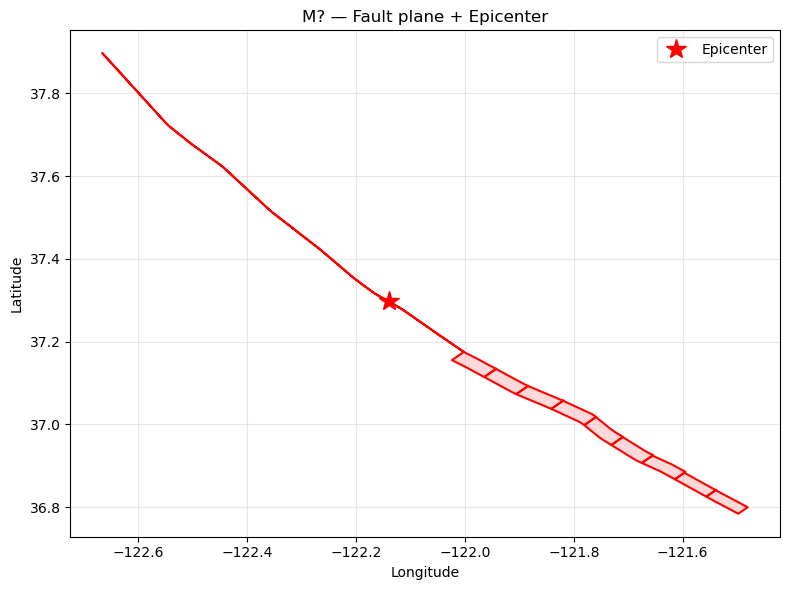

In [3]:
# Parse rupture.json and plot the fault plane
rup = json.loads((EVENT_DIR / 'rupture.json').read_text())
print(f'Rupture reference: {rup.get("metadata", {}).get("reference", "n/a")}')

fig, ax = plt.subplots(figsize=(8, 6))
for feat in rup['features']:
    geom = feat['geometry']
    if geom['type'] == 'MultiPolygon':
        for polygon in geom['coordinates']:
            for ring in polygon:
                lons = [c[0] for c in ring]
                lats = [c[1] for c in ring]
                ax.plot(lons, lats, 'r-', linewidth=1.5)
                ax.fill(lons, lats, alpha=0.15, color='red')

epi_lon = float(ev.get('lon', 0))
epi_lat = float(ev.get('lat', 0))
ax.plot(epi_lon, epi_lat, '*', color='red', markersize=15,
        zorder=5, label='Epicenter')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'M{ev.get("magnitude","?")} — Fault plane + Epicenter')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Run ShakeMap

A `model.conf` clips the extent to the significant shaking area and sets 1.5 km
resolution — keeping the run under 60 seconds while covering everything above MMI V.

Modules:
- **`assemble`** — collect inputs
- **`model`** — compute ground motion (~55s)
- **`contour`** — shaking contours
- **`mapping`** — render maps (~45s)
- **`gridxml`** — export grid for ground failure

In [4]:
conf = EVENT_DIR / 'model.conf'
print('model.conf:' if conf.exists() else 'WARNING: model.conf not found')
if conf.exists():
    print(conf.read_text())

model.conf:
[extent]
    [[bounds]]
        extent = -124.4, 34.8, -118.9, 40.1

[interp]
    [[prediction_location]]
        xres = 1.5k
        yres = 1.5k
        nmax = 500000



In [5]:
%%bash
shake $EVENT assemble -c 'demo' model contour mapping gridxml 2>&1 \
  | grep -E 'Running|Finished|ERROR'

INFO -- 2026-08-06 18:34:11 -- shake.main -- Running command assemble
INFO -- 2026-08-06 18:34:11 -- shake.main -- Finished running command assemble: Elapsed 0.15 secs
INFO -- 2026-08-06 18:34:11 -- shake.main -- Running command model
INFO -- 2026-08-06 18:35:05 -- shake.main -- Finished running command model: Elapsed 54.00 secs
INFO -- 2026-08-06 18:35:05 -- shake.main -- Running command contour
INFO -- 2026-08-06 18:35:07 -- shake.main -- Finished running command contour: Elapsed 1.61 secs
INFO -- 2026-08-06 18:35:07 -- shake.main -- Running command mapping
INFO -- 2026-08-06 18:35:50 -- shake.main -- Finished running command mapping: Elapsed 43.03 secs
INFO -- 2026-08-06 18:35:50 -- shake.main -- Running command gridxml
INFO -- 2026-08-06 18:35:51 -- shake.main -- Finished running command gridxml: Elapsed 1.16 secs


In [9]:
print('Output products:')
for f in sorted(PRODUCTS.glob('*')):
    print(f'  {f.name:45s} {f.stat().st_size/1e6:.1f} MB')

Output products:
  cont_mi.json                                  0.0 MB
  cont_mmi.json                                 0.0 MB
  cont_pga.json                                 0.0 MB
  cont_pgv.json                                 0.0 MB
  cont_psa0p3.json                              0.0 MB
  cont_psa1p0.json                              0.0 MB
  cont_psa3p0.json                              0.0 MB
  grid.xml                                      7.3 MB
  intensity.jpg                                 0.1 MB
  intensity.pdf                                 3.1 MB
  intensity_overlay.png                         0.1 MB
  intensity_overlay.pngw                        0.0 MB
  mmi_legend.png                                0.0 MB
  pga.jpg                                       0.1 MB
  pga.pdf                                       3.1 MB
  pgv.jpg                                       0.1 MB
  pgv.pdf                                       3.1 MB
  pin-thumbnail.png                             

## 4. ShakeMap outputs

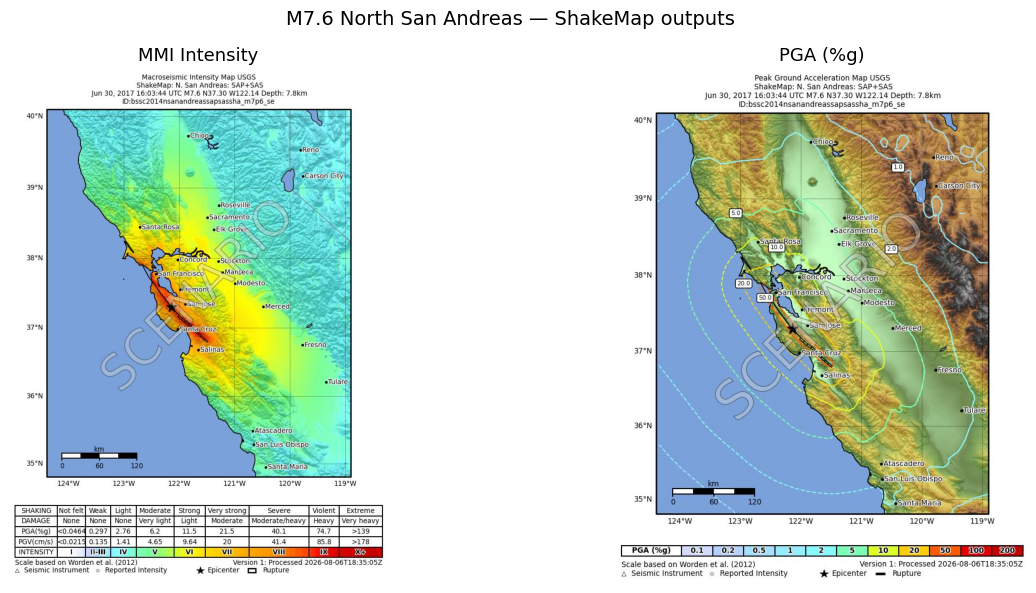

Finite fault intensity map saved for later comparison


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, title in [
    (axes[0], 'intensity.jpg', 'MMI Intensity'),
    (axes[1], 'pga.jpg',       'PGA (%g)'),
]:
    img_path = PRODUCTS / name
    if img_path.exists():
        ax.imshow(mpimg.imread(img_path))
    else:
        ax.text(0.5, 0.5, f'{name} not found',
                ha='center', transform=ax.transAxes)
    ax.set_title(title, fontsize=13); ax.axis('off')
plt.suptitle('M7.6 North San Andreas — ShakeMap outputs', fontsize=14)
plt.tight_layout(); plt.show()

# Save for later comparison with point source
shutil.copy(PRODUCTS / 'intensity.jpg',
            Path.home() / 'san_andreas_ff_intensity.jpg')
print('Finite fault intensity map saved for later comparison')

### Shaking at key cities

Scenario planners need shaking estimates at specific locations — not just maps.
Emergency managers want to know: what MMI and PGA does San Francisco experience?
How does that compare to the 1989 Loma Prieta earthquake?

We can extract these values directly from the ShakeMap grid.

In [26]:
cities = {
    'San Francisco': (37.775, -122.419),
    'Oakland':       (37.804, -122.271),
    'San Jose':      (37.338, -121.886),
    'Santa Cruz':    (36.974, -122.031),
    'Salinas':       (36.677, -121.655),
    'Monterey':      (36.600, -121.894),
    'Fresno':        (36.747, -119.772),
}

# Loma Prieta 1989 reference values for context
loma_prieta = {
    'San Francisco': 7.0,
    'Oakland':       7.5,
    'San Jose':      7.0,
    'Santa Cruz':    9.0,
    'Salinas':       6.0,
    'Monterey':      7.0,
    'Fresno':        4.0,
}

cities_mmi_ff = {}
for city, (lat, lon) in cities.items():
    dist = np.sqrt((data[:, fields['LAT']] - lat)**2 +
                   (data[:, fields['LON']] - lon)**2)
    cities_mmi_ff[city] = data[np.argmin(dist), fields['MMI']]

data, fields = load_grid(PRODUCTS / 'grid.xml')

print(f'{"City":15s} {"MMI (M7.6)":>12s} {"LP 1989 MMI":>12s} '
      f'{"PGA(%g)":>10s} {"PGV(cm/s)":>10s}')
print('-' * 65)
for city, (lat, lon) in cities.items():
    dist = np.sqrt((data[:, fields['LAT']] - lat)**2 +
                   (data[:, fields['LON']] - lon)**2)
    idx = np.argmin(dist)
    mmi = data[idx, fields['MMI']]
    pga = data[idx, fields['PGA']]
    pgv = data[idx, fields['PGV']]
    lp  = loma_prieta.get(city, '—')
    diff = f'(+{mmi-lp:.1f})' if isinstance(lp, float) else ''
    print(f'{city:15s} {mmi:12.1f} {str(lp):>12s} '
          f'{pga:10.1f} {pgv:10.1f}  {diff}')

City              MMI (M7.6)  LP 1989 MMI    PGA(%g)  PGV(cm/s)
-----------------------------------------------------------------
San Francisco            6.9          7.0       17.3       24.5  (+-0.1)
Oakland                  6.8          7.5       17.3       24.0  (+-0.7)
San Jose                 7.8          7.0       32.7       48.9  (+0.8)
Santa Cruz               7.4          9.0       24.9       36.5  (+-1.6)
Salinas                  6.4          6.0       12.3       17.0  (+0.4)
Monterey                 6.2          7.0       12.6       15.1  (+-0.8)
Fresno                   4.9          4.0        2.9        6.0  (+0.9)


**Discussion:** How does the M7.6 scenario compare to the 1989 Loma Prieta M6.9?
Which cities see the largest difference? What does this tell us about the hazard
from a full North San Andreas rupture vs a smaller event on a nearby fault segment?

## 5. PAGER — Loss Estimates

PAGER combines ShakeMap shaking with population exposure and building vulnerability
to estimate fatalities and economic losses. Key things to look for:

- **Alert level** — green/yellow/orange/red for fatalities and losses separately
- **Population exposure table** — people at each MMI level
- **Historical analogs** — past earthquakes that calibrate the model
- **Structures note** — building stock description for this region

Why are there separate alerts for fatalities and economic losses?
California has relatively earthquake-resistant construction (strict building codes)
but extremely high property values — so economic losses dominate.

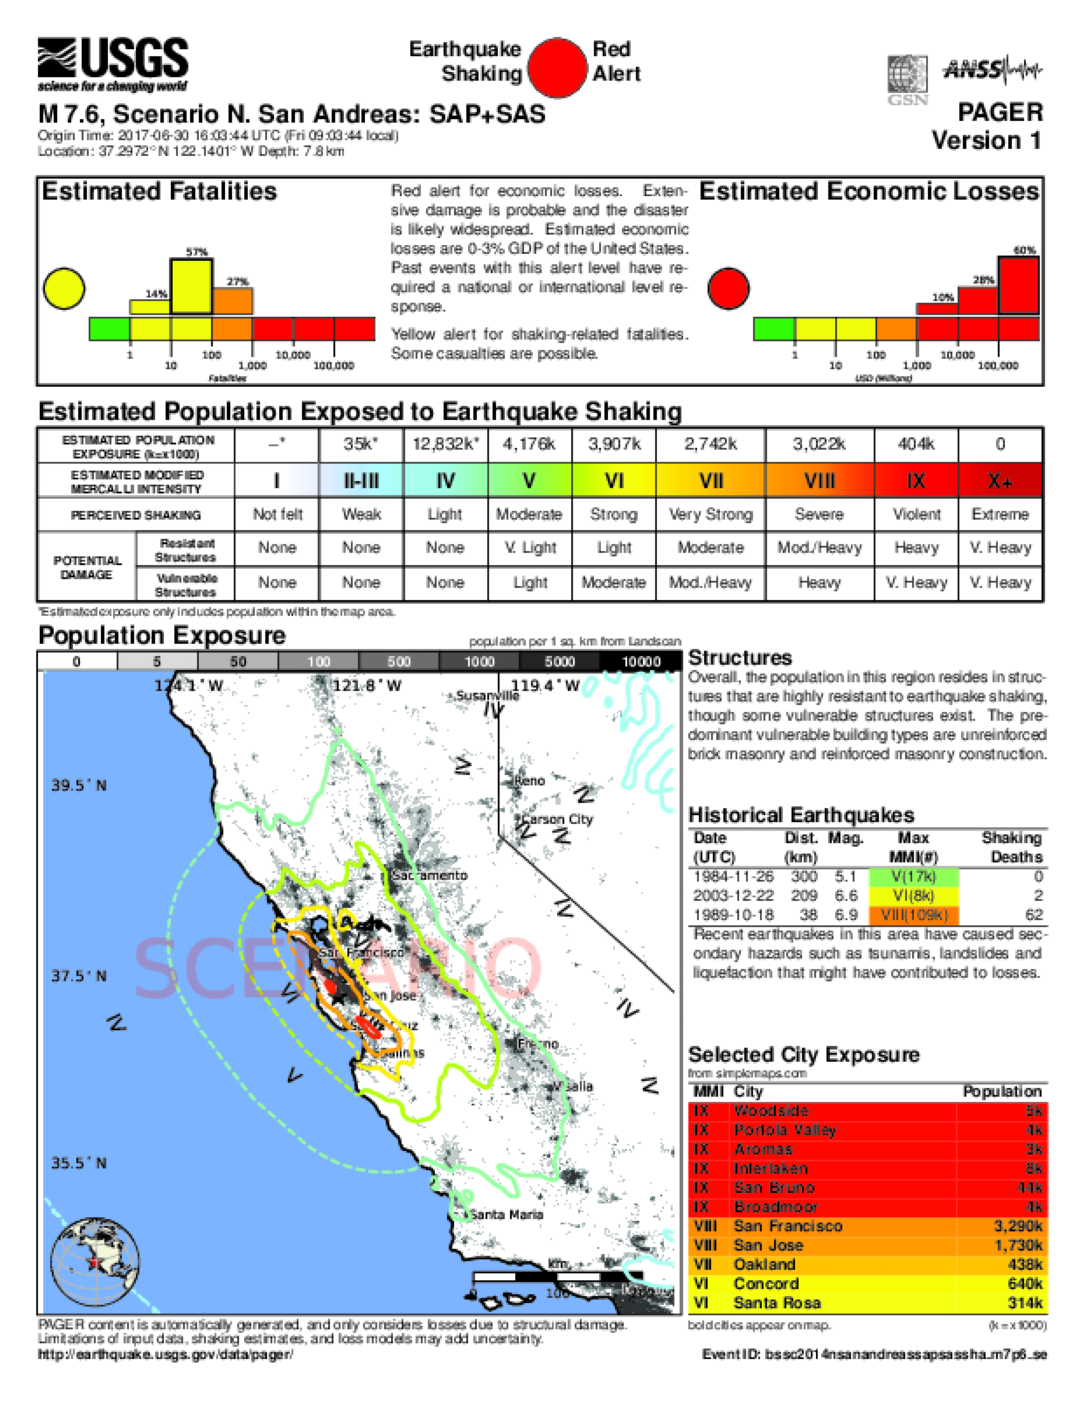

In [12]:
img = mpimg.imread(str(PAGER_PNG))
fig, ax = plt.subplots(figsize=(11, 15))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Ground failure

Ground failure models use the ShakeMap `grid.xml` to estimate secondary hazards:
- **Landslide probability** — Nowicki Jessee et al. (2018)
- **Liquefaction probability** — Zhu et al. (2017)

The Santa Cruz Mountains (high landslide hazard) and the Bay mud deposits
(high liquefaction hazard) make this a particularly instructive scenario.

In [13]:
print(f'CA inputs: {CA_DATA.exists()}')
print(f'Grid:      {(PRODUCTS / "grid.xml").exists()}')

CA inputs: True
Grid:      True


In [14]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  ~/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -d /workspaces/shakemap-codespaces/data/california_inputs \
  2>&1 | grep -E 'Running|zipping|ERROR|bounds'

Running the following models:
Applying bounds of lonmin -124.40, lonmax -118.89, latmin 34.79, latmax 40.10


In [15]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  ~/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -d /workspaces/shakemap-codespaces/data/california_inputs \
  2>&1 | grep -E 'Running|zipping|ERROR|bounds'

Running the following models:
Applying bounds of lonmin -124.40, lonmax -118.89, latmin 34.79, latmax 40.10


In [16]:
print('Ground failure outputs:')
for f in sorted(GF_OUT.glob('*.tif')):
    print(f'  {f.name}')

Ground failure outputs:
  bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif
  bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif


## 7. Interactive ground failure map

Landslide (left) and liquefaction (right) side by side with shaking contours.
Click anywhere to see coordinates. Toggle layers bottom-right.

In [17]:
%%bash
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --ls-model "Jessee 2018:$HOME/gf_output/$EVENT/${EVENT}_jessee_2018_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini" \
  --lq-model "Zhu 2017:$HOME/gf_output/$EVENT/${EVENT}_zhu_2017_general_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --outfile ~/san_andreas_gf.html 2>&1 | tail -5

Loading [LS] Jessee 2018
Loading [LQ] Zhu 2017
Saved: /home/vscode/san_andreas_gf.html
[LS] Jessee 2018: max P=0.2372, area>0.002: 6.1%
[LQ] Zhu 2017: max P=0.4280, area>0.002: 35.5%


In [19]:
import base64
from IPython.display import HTML

html_path = Path.home() / 'san_andreas_gf.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:452: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


---
## 8. Try it yourself

The cells below let you modify the scenario and see how the results change.
These are the kinds of sensitivity tests that scenario planners run routinely.

### Modification 1: Point source vs. finite fault

Remove the rupture geometry and re-run as a point source. This shows how much
directivity and rupture extent matter for a large earthquake on a long fault.

**Expected:** circular symmetric shaking vs. elongated directivity pattern.

In [20]:
# Back up and remove the rupture file
rupture_file   = EVENT_DIR / 'rupture.json'
rupture_backup = EVENT_DIR / 'rupture.json.bak'
shutil.copy(rupture_file, rupture_backup)
rupture_file.unlink()
print('Rupture file removed — ShakeMap will use a point source')

Rupture file removed — ShakeMap will use a point source


In [21]:
%%bash
shake $EVENT assemble -c 'point source' model contour mapping 2>&1 \
  | grep -E 'Running|Finished|ERROR'

INFO -- 2026-08-06 18:40:05 -- shake.main -- Running command assemble
INFO -- 2026-08-06 18:40:05 -- shake.main -- Finished running command assemble: Elapsed 0.06 secs
INFO -- 2026-08-06 18:40:05 -- shake.main -- Running command model
INFO -- 2026-08-06 18:40:11 -- shake.main -- Finished running command model: Elapsed 6.37 secs
INFO -- 2026-08-06 18:40:11 -- shake.main -- Running command contour
INFO -- 2026-08-06 18:40:13 -- shake.main -- Finished running command contour: Elapsed 1.59 secs
INFO -- 2026-08-06 18:40:13 -- shake.main -- Running command mapping
INFO -- 2026-08-06 18:40:53 -- shake.main -- Finished running command mapping: Elapsed 39.93 secs


In [24]:
%%bash
shake $EVENT gridxml 2>&1 \
  | grep -E 'Running|Finished|ERROR'

INFO -- 2026-08-06 18:43:05 -- shake.main -- Running command gridxml
INFO -- 2026-08-06 18:43:06 -- shake.main -- Finished running command gridxml: Elapsed 1.13 secs


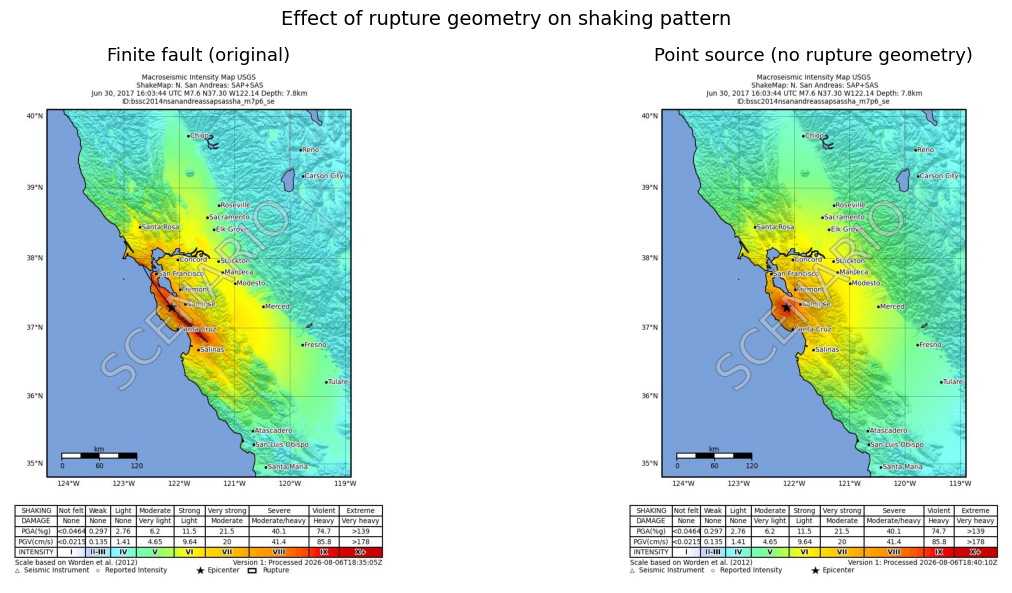

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, path, title in [
    (axes[0],
     Path.home() / 'san_andreas_ff_intensity.jpg',
     'Finite fault (original)'),
    (axes[1],
     PRODUCTS / 'intensity.jpg',
     'Point source (no rupture geometry)'),
]:
    if path.exists():
        ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=13); ax.axis('off')
plt.suptitle('Effect of rupture geometry on shaking pattern', fontsize=14)
plt.tight_layout(); plt.show()

In [27]:
data_ps, fields_ps = load_grid(PRODUCTS / 'grid.xml')
print(f'{"City":15s} {"MMI finite fault":>18s} {"MMI point source":>18s} {"Difference":>12s}')
print('-' * 68)
for city, (lat, lon) in cities.items():
    dist = np.sqrt((data_ps[:, fields_ps['LAT']] - lat)**2 +
                   (data_ps[:, fields_ps['LON']] - lon)**2)
    mmi_ps = data_ps[np.argmin(dist), fields_ps['MMI']]
    mmi_ff = cities_mmi_ff.get(city, float('nan'))
    print(f'{city:15s} {mmi_ff:18.1f} {mmi_ps:18.1f} {mmi_ps-mmi_ff:+12.1f}')

City              MMI finite fault   MMI point source   Difference
--------------------------------------------------------------------
San Francisco                  7.8                6.9         -0.9
Oakland                        7.3                6.8         -0.5
San Jose                       7.6                7.8         +0.2
Santa Cruz                     7.5                7.4         -0.1
Salinas                        7.5                6.4         -1.1
Monterey                       5.9                6.2         +0.3
Fresno                         5.3                4.9         -0.4


In [28]:
# Restore the rupture file
shutil.copy(rupture_backup, rupture_file)
rupture_backup.unlink()
print('Rupture file restored')

Rupture file restored


---
## 9. How scenario planners use these results

The pipeline you just ran — ShakeMap → PAGER → Ground Failure — is the same
workflow USGS uses operationally for real earthquakes. For **scenario planning**,
the same tools are used to answer planning questions before an earthquake occurs.

### Typical scenario planning workflow

1. **Select a credible fault** — from PSHA disaggregation (what fault dominates
   the hazard at the target return period?) or from historical precedent.

2. **Define rupture parameters** — magnitude from scaling relationships
   (Wells & Coppersmith or newer), fault geometry from the USGS fault database
   or published models. This is what `event.xml` and `rupture.json` contain.

3. **Run ShakeMap** — with appropriate GMPEs for the tectonic setting
   (shallow crustal, subduction, stable continental). For Turkey, GMPEs
   calibrated to Turkish strong motion data may be preferred over global models.

4. **Run PAGER** — to estimate consequence. This drives emergency management
   planning: how many people need evacuation? What is the economic impact?

5. **Run ground failure** — to identify secondary hazard zones: which roads
   may be blocked by landslides? Which areas face liquefaction-driven
   infrastructure damage?

6. **Sensitivity testing** — run variants (different fault segments, different
   magnitudes, different depths) to understand the range of possible outcomes.
   This is what you did in section 8.

---
**End of demo.**  
Download `san_andreas_gf.html` from the Explorer (right-click → Download)
to open the interactive ground failure map in a browser.